In [1]:
import sys 
sys.path.append("/Users/users/wempe/lgsim")
from lgsim.postprocess_gadget import *
from pathlib import Path

In [2]:
fol = Path("/net/gaia2/data/users/wempe/rerun_169/")
folnames_new = sorted([x.parent for x in list(fol.glob("*/snapshot_209.hdf5"))])

In [3]:
# fol = Path("/net/gaia2/data/users/wempe/lr/")
# folnames_new = sorted([x.parent for x in list(fol.glob("*/snapshot_209.hdf5"))])
# #70 more LR simulations

In [4]:
print(fol) #mergers.nc

/net/gaia2/data/users/wempe/rerun_169


In [5]:
fol = folnames_new[128]

In [6]:
print(fol) #mergers.nc

/net/gaia2/data/users/wempe/rerun_169/runz98.7_mcmc_1189


In [7]:
import xarray as xr

ds = xr.open_dataset(
    fol / "mergers_m31.nc",
    engine="h5netcdf",
    phony_dims="sort"
)

In [8]:
#!pip install --user netCDF4

In [9]:
xr.open_dataset(fol / "mergers_mw.nc")

<xarray.Dataset>
Dimensions:                 (snap_subhalo_id: 225, which: 3, event: 8, xyz: 3)
Coordinates:
  * which                   (which) object 'subhalo' 'main' 'mmp'
  * event                   (event) object 'birth' 'fof_first' ... 'destroyed'
Dimensions without coordinates: snap_subhalo_id, xyz
Data variables: (12/42)
    SubhaloCM               (snap_subhalo_id, which, event, xyz) float32 ...
    SubhaloGroupNr          (snap_subhalo_id, which, event) int64 ...
    SubhaloHalfmassRad      (snap_subhalo_id, which, event) float32 ...
    SubhaloHalfmassRadType  (snap_subhalo_id, which, event, xyz) float32 ...
    SubhaloIDMostbound      (snap_subhalo_id, which, event) uint32 ...
    SubhaloLen              (snap_subhalo_id, which, event) int32 ...
    ...                      ...
    Group_R_Mean200         (snap_subhalo_id, which, event) float32 ...
    Group_R_TopHat200       (snap_subhalo_id, which, event) float32 ...
    Group                   (snap_subhalo_id, which, event) float64 ...
    snapnum                 (snap_subhalo_id, event) int64 ...
    ends_in_mw              (snap_subhalo_id) bool ...
    survives_to_now         (snap_subhalo_id) bool ...
Attributes:
    Ngroups_ThisFile:    2291
    Nsubhalos_ThisFile:  2604
    Nids_ThisFile:       841277
    Ngroups_Total:       2291
    Nsubhalos_Total:     2604
    Nids_Total:          841277
    NumFiles:            1
    Time:                0.9524316709088371
    Redshift:            0.04994408580068721
    BoxSize:             27.0224
    Git_commit:          8d3322bf88cee5f32a4309ddc3dc04830808904c
    Git_date:            Tue Jul 25 13:54:51 2023 +0200

In [10]:
ds = xr.open_dataset(fol / "mergers_mw.nc")

In [11]:
import xarray as xr
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

#save original function
_real_load_dataset = xr.load_dataset

def fixed_load_dataset(*args, **kwargs):
    kwargs["engine"] = "h5netcdf"
    kwargs["phony_dims"] = "sort"
    return _real_load_dataset(*args, **kwargs)

#monkey patch xarray
xr.load_dataset = fixed_load_dataset

In [12]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

mt = MergerTree(fol, Nsnap=209)

In [13]:
mergers_ds = xr.open_dataset(fol / "mergers_mw.nc")

In [14]:
mergers_ds['massratio'] = mergers_ds.sel(which='subhalo', event='sat_highestmass').SubhaloMass / mergers_ds.sel(which='mmp', event='sat_highestmass').SubhaloMass

In [15]:
gres = GadgetRes(fol, i_snap=0)

In [16]:
from astropy.cosmology import Planck18
from astropy import units as u
import numpy as np

def sf_to_lookback(a):
    a = np.asarray(a, dtype=float)
    z = 1 / a - 1
    return Planck18.lookback_time(z).to_value(u.Gyr)

In [17]:
mt.groups[209]

<xarray.Dataset>
Dimensions:            (Group: 2311, xyz: 3)
Coordinates:
  * Group              (Group) int64 0 1 2 3 4 5 ... 2306 2307 2308 2309 2310
Dimensions without coordinates: xyz
Data variables: (12/18)
    GroupAscale        (Group) float32 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    GroupFirstSub      (Group) int64 0 31 64 81 101 ... 2593 2594 2595 2596 2597
    GroupLen           (Group) int32 116603 91940 40453 33625 ... 32 32 32 32
    GroupLenType       (Group, xyz) int32 0 0 116603 0 0 91940 ... 0 0 32 0 0 32
    GroupMass          (Group) float32 148.5 117.1 51.51 ... 0.04074 0.04074
    GroupMassType      (Group, xyz) float32 0.0 0.0 148.5 ... 0.0 0.0 0.04074
    ...                 ...
    Group_M_Mean200    (Group) float32 169.8 130.9 57.45 ... 0.04074 0.04074
    Group_M_TopHat200  (Group) float32 156.0 119.4 48.63 ... 0.03947 0.03565
    Group_R_Crit200    (Group) float32 0.1814 0.1645 0.1209 ... 0.01153 0.0111
    Group_R_Crit500    (Group) float32 0.124 0.1083 ... 0.008394 0.007467
    Group_R_Mean200    (Group) float32 0.2861 0.2623 0.1993 ... 0.01778 0.01778
    Group_R_TopHat200  (Group) float32 0.2355 0.2154 0.1597 ... 0.01489 0.0144
Attributes:
    BoxSize:             27.0224
    Git_commit:          8d3322bf88cee5f32a4309ddc3dc04830808904c
    Git_date:            Tue Jul 25 13:54:51 2023 +0200
    Ngroups_ThisFile:    2311
    Ngroups_Total:       2311
    Nids_ThisFile:       856682
    Nids_Total:          856682
    Nsubhalos_ThisFile:  2598
    Nsubhalos_Total:     2598
    NumFiles:            1
    Redshift:            4.440892098500626e-16
    Time:                0.9999999999999997

In [18]:
mt.subhalos[209]

<xarray.Dataset>
Dimensions:                 (Subhalo: 2598, xyz: 3)
Coordinates:
  * Subhalo                 (Subhalo) int64 0 1 2 3 4 ... 2594 2595 2596 2597
    Group                   (Subhalo) int64 0 0 0 0 0 ... 2307 2308 2309 2310
Dimensions without coordinates: xyz
Data variables: (12/36)
    SubhaloCM               (Subhalo, xyz) float32 14.08 13.5 ... 13.64 18.57
    SubhaloGroupNr          (Subhalo) int64 0 0 0 0 0 ... 2307 2308 2309 2310
    SubhaloHalfmassRad      (Subhalo) float32 0.07412 0.006926 ... 0.005176
    SubhaloHalfmassRadType  (Subhalo, xyz) float32 0.0 0.0 ... 0.0 0.005176
    SubhaloIDMostbound      (Subhalo) uint32 1462969 1184168 ... 1636296 2329457
    SubhaloLen              (Subhalo) int32 113031 907 392 378 ... 32 32 32 32
    ...                      ...
    Group_M_Mean200         (Subhalo) float32 169.8 169.8 ... 0.04074 0.04074
    Group_M_TopHat200       (Subhalo) float32 156.0 156.0 ... 0.03947 0.03565
    Group_R_Crit200         (Subhalo) float32 0.1814 0.1814 ... 0.01153 0.0111
    Group_R_Crit500         (Subhalo) float32 0.124 0.124 ... 0.008394 0.007467
    Group_R_Mean200         (Subhalo) float32 0.2861 0.2861 ... 0.01778 0.01778
    Group_R_TopHat200       (Subhalo) float32 0.2355 0.2355 ... 0.01489 0.0144
Attributes:
    BoxSize:             27.0224
    Git_commit:          8d3322bf88cee5f32a4309ddc3dc04830808904c
    Git_date:            Tue Jul 25 13:54:51 2023 +0200
    Ngroups_ThisFile:    2311
    Ngroups_Total:       2311
    Nids_ThisFile:       856682
    Nids_Total:          856682
    Nsubhalos_ThisFile:  2598
    Nsubhalos_Total:     2598
    NumFiles:            1
    Redshift:            4.440892098500626e-16
    Time:                0.9999999999999997

In [19]:
from astropy.cosmology import Planck18
from astropy import units as u
import matplotlib.pyplot as plt
import numpy as np

/Users/users/wempe/lgsim/lgsim/postprocess_gadget.py:318: RuntimeWarning: divide by zero encountered in divide
  x_axis_values = Planck18.age(1/a_s-1).to_value(u.Gyr)


(0.0, 14.0)

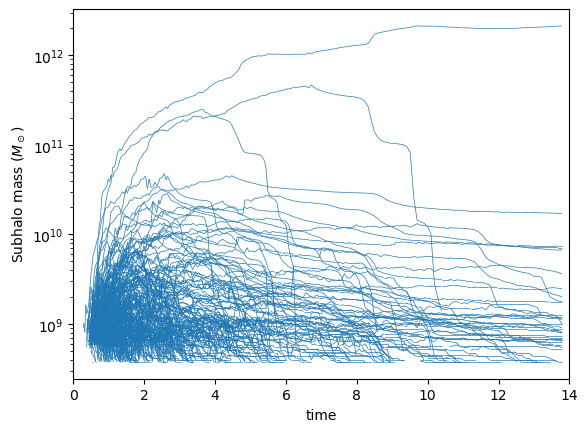

In [20]:
tree1 = mt.plot_mergertree(mt.i_m31all, axis='lookback_time')
plt.xlabel('time')
plt.xlim(0,14)

(0.0, 14.0)

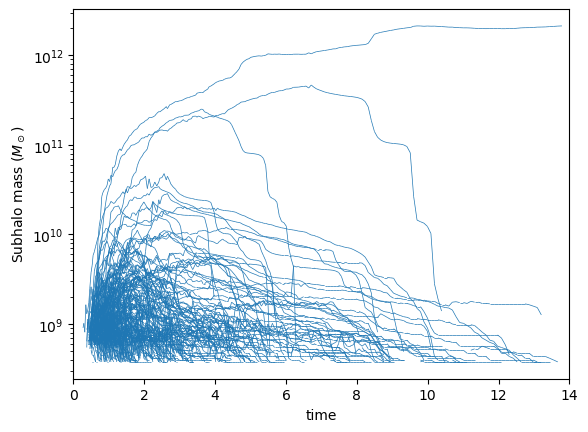

In [21]:
tree1 = mt.plot_mergertree(mt.i_m31, axis='lookback_time')
plt.xlabel('time')
plt.xlim(0,14)

Text(0.5, 0, 'Lookback time [Gyr]')

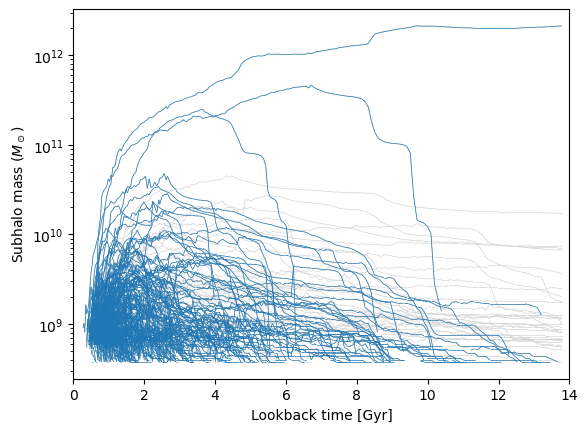

In [22]:
mt.plot_mergertree(mt.i_m31all, axis="lookback_time", color="lightgrey")
mt.plot_mergertree(mt.i_m31, axis="lookback_time")

plt.xlim(0, 14)
plt.xlabel("Lookback time [Gyr]")